In [1]:
import os
import gc
import json
import copy
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Dict

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# Reduce TensorFlow logging noise
tf.get_logger().setLevel("ERROR")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Imports complete")

Imports complete


In [2]:
# =========================
# USER SETTINGS
# =========================

DATA_PATH = "DATASET.csv"  # Set to the downloaded data path
CACHE_DIR = "cache_fast_fl_pipeline"
MODEL_DIR = os.path.join(CACHE_DIR, "models")
RESULT_DIR = os.path.join(CACHE_DIR, "results")

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# Crash/restart behaviour
FORCE_REBUILD_DATA = False
FORCE_RETRAIN_LSTM = False
FORCE_REBUILD_PREDICTIONS = False
FORCE_RETRAIN_PPO = False
FORCE_REEVALUATE = False

RANDOM_STATE = 42
N_FED_HOMES = 20
TEST_SIZE = 0.2

# Hourly sequence settings
SEQ_LEN = 72          # 3 days of hourly history. Use 168 for 7 days, 720 for 30 days.
HORIZON = 6           # predict next 6 hours
LOCAL_EPOCHS = 1
BATCH_SIZE = 64

# Federated LSTM speed controls
MAX_FL_DAYS = 45      # use None for all available days
LSTM_UNITS = 16

# Federated PPO speed controls
PPO_ROUNDS = 4
PPO_HOMES_PER_ROUND = 8
PPO_LOCAL_TIMESTEPS = 500

# Battery parameters
BATTERY_CAPACITY_KWH = 3.0
MAX_C_RATE = 0.5
CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95
INITIAL_SOC_FRAC = 0.5
WASTE_PENALTY_PER_KWH = 0.0
THROUGHPUT_PENALTY_PER_KWH = 0.001

print("Cache directory:", CACHE_DIR)

Cache directory: cache_fast_fl_pipeline


In [3]:
# =========================
# CACHE HELPERS
# =========================

def cache_exists(path):
    return os.path.exists(path)


def save_pickle(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=4, default=str)


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def stage_message(name, loaded):
    print(("Loaded cached" if loaded else "Built") + f" stage: {name}")

## Stage 1 — Load, clean, feature engineer, sample homes

This stage is cached as `stage1_data.pkl`. If the notebook crashes later, rerunning starts from this cached dataframe.

In [4]:
stage1_path = os.path.join(CACHE_DIR, "stage1_data.pkl")

if cache_exists(stage1_path) and not FORCE_REBUILD_DATA:
    df, df_fed, feature_cols = load_pickle(stage1_path)
    stage_message("stage1_data", loaded=True)
else:
    raw_df = pd.read_csv(DATA_PATH)
    df = raw_df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values(["homeid", "timestamp"]).reset_index(drop=True)

    # Rebuild time features from timestamp, avoiding stale columns
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["month"] = df["timestamp"].dt.month
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = df.drop(columns=["hour", "day_of_week", "month"], errors="ignore")

    exclude_cols = ["timestamp", "homeid", "price_kwh_original"]
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    clean_cols = list(dict.fromkeys(feature_cols + ["demand_kwh", "solar_kwh", "price_kwh"]))
    df[clean_cols] = df[clean_cols].replace([np.inf, -np.inf], np.nan)
    df[clean_cols] = df.groupby("homeid")[clean_cols].transform(lambda x: x.ffill().bfill())
    df[clean_cols] = df[clean_cols].fillna(0)

    # Use fixed sample for faster experiments
    all_homes = df["homeid"].drop_duplicates()
    sample_homes = all_homes.sample(
        n=min(N_FED_HOMES, len(all_homes)),
        random_state=RANDOM_STATE
    )
    df_fed = df[df["homeid"].isin(sample_homes)].copy().reset_index(drop=True)

    save_pickle((df, df_fed, feature_cols), stage1_path)
    stage_message("stage1_data", loaded=False)

print("Full df:", df.shape)
print("Federated subset:", df_fed.shape)
print("Homes used:", df_fed["homeid"].nunique())
print("Features:", len(feature_cols), feature_cols)

Built stage: stage1_data
Full df: (84924, 14)
Federated subset: (33725, 14)
Homes used: 20
Features: 11 ['demand_kwh', 'solar_kwh', 'price_kwh', 'is_weekend', 'outdoor_temperature', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## Stage 2 — Train/test split per home

In [5]:
def split_df_per_home(df, test_size=0.2):
    train_parts = []
    test_parts = []
    df = df.sort_values(["homeid", "timestamp"])

    for homeid, group in df.groupby("homeid"):
        split_idx = int(len(group) * (1 - test_size))
        train_parts.append(group.iloc[:split_idx])
        test_parts.append(group.iloc[split_idx:])

    return (
        pd.concat(train_parts).reset_index(drop=True),
        pd.concat(test_parts).reset_index(drop=True)
    )

stage2_path = os.path.join(CACHE_DIR, "stage2_split.pkl")

if cache_exists(stage2_path) and not FORCE_REBUILD_DATA:
    train_df, test_df = load_pickle(stage2_path)
    stage_message("stage2_split", loaded=True)
else:
    train_df, test_df = split_df_per_home(df_fed, test_size=TEST_SIZE)
    save_pickle((train_df, test_df), stage2_path)
    stage_message("stage2_split", loaded=False)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Built stage: stage2_split
Train rows: 26968
Test rows: 6757


## Core FL/LSTM helpers

In [6]:
def make_sequences_from_window(group, feature_cols, target_col, seq_len, horizon, x_scaler, y_scaler):
    group = group.sort_values("timestamp").reset_index(drop=True)

    X_vals = group[feature_cols].to_numpy(dtype=np.float32)
    y_vals = group[target_col].to_numpy(dtype=np.float32)

    X, y = [], []
    for i in range(len(group) - seq_len - horizon + 1):
        X.append(X_vals[i:i + seq_len])
        y.append(y_vals[i + seq_len:i + seq_len + horizon])

    if len(X) == 0:
        return None, None

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    n_features = X.shape[2]
    X = x_scaler.transform(X.reshape(-1, n_features)).reshape(X.shape)
    y = y_scaler.transform(y.reshape(-1, 1)).reshape(y.shape)

    return X, y


def build_lstm_model(seq_len, n_features, horizon, lstm_units=16):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(lstm_units),
        Dense(16, activation="relu"),
        Dense(horizon)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model


def fedavg_weighted(local_weights, sample_counts):
    total_samples = np.sum(sample_counts)
    averaged_weights = []

    for weights_tuple in zip(*local_weights):
        weighted = np.zeros_like(weights_tuple[0])
        for weights, n in zip(weights_tuple, sample_counts):
            weighted += weights * (n / total_samples)
        averaged_weights.append(weighted)

    return averaged_weights

In [7]:
def rolling_federated_lstm_training(
    train_df,
    target_col,
    feature_cols,
    seq_len,
    horizon,
    local_epochs=1,
    batch_size=64,
    max_days=None,
    lstm_units=16,
):
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    x_scaler.fit(train_df[feature_cols].to_numpy(dtype=np.float32))
    y_scaler.fit(train_df[[target_col]].to_numpy(dtype=np.float32))

    global_model = build_lstm_model(
        seq_len=seq_len,
        n_features=len(feature_cols),
        horizon=horizon,
        lstm_units=lstm_units,
    )

    train_df = train_df.copy()
    train_df["timestamp"] = pd.to_datetime(train_df["timestamp"], errors="coerce")
    train_df = train_df.dropna(subset=["timestamp"])
    train_df = train_df.sort_values(["homeid", "timestamp"]).reset_index(drop=True)

    unique_days = sorted(train_df["timestamp"].dt.floor("D").unique())
    if max_days is not None:
        unique_days = unique_days[-max_days:]

    history_log = []
    min_required = seq_len + horizon
    grouped = list(train_df.groupby("homeid"))

    for day_idx, current_day in enumerate(unique_days):
        day_end = pd.Timestamp(current_day) + pd.Timedelta(days=1)
        local_weights = []
        sample_counts = []

        for homeid, home_df in grouped:
            window_start = day_end - pd.Timedelta(hours=min_required)
            local_window = home_df[
                (home_df["timestamp"] >= window_start) &
                (home_df["timestamp"] < day_end)
            ]

            if len(local_window) < min_required:
                continue

            X_local, y_local = make_sequences_from_window(
                group=local_window,
                feature_cols=feature_cols,
                target_col=target_col,
                seq_len=seq_len,
                horizon=horizon,
                x_scaler=x_scaler,
                y_scaler=y_scaler,
            )

            if X_local is None:
                continue

            local_model = clone_model(global_model)
            local_model.set_weights(global_model.get_weights())
            local_model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                loss=tf.keras.losses.Huber(),
                metrics=["mae"],
            )

            local_model.fit(
                X_local,
                y_local,
                epochs=local_epochs,
                batch_size=batch_size,
                verbose=0,
                shuffle=True,
            )

            local_weights.append(local_model.get_weights())
            sample_counts.append(len(X_local))

            del local_model
            gc.collect()

        if len(local_weights) > 0:
            global_model.set_weights(fedavg_weighted(local_weights, sample_counts))
            history_log.append({
                "day": current_day,
                "num_clients": len(local_weights),
                "num_samples": int(np.sum(sample_counts)),
            })

        if day_idx % 5 == 0:
            print(f"{target_col} | Day {day_idx + 1}/{len(unique_days)} | {pd.Timestamp(current_day).date()} | clients={len(local_weights)}")

    return global_model, x_scaler, y_scaler, pd.DataFrame(history_log)

## Stage 3 — Train/load FL/LSTM demand and price models

In [8]:
def train_or_load_fl_lstm(target_col, model_name):
    model_path = os.path.join(MODEL_DIR, f"{model_name}.keras")
    x_scaler_path = os.path.join(MODEL_DIR, "x_scaler.pkl")
    y_scaler_path = os.path.join(MODEL_DIR, f"{model_name}_y_scaler.pkl")
    history_path = os.path.join(RESULT_DIR, f"{model_name}_history.csv")

    if (
        cache_exists(model_path)
        and cache_exists(x_scaler_path)
        and cache_exists(y_scaler_path)
        and not FORCE_RETRAIN_LSTM
    ):
        print(f"Loading cached {model_name}...")
        model = load_model(model_path)
        x_scaler = joblib.load(x_scaler_path)
        y_scaler = joblib.load(y_scaler_path)
        history = pd.read_csv(history_path) if cache_exists(history_path) else pd.DataFrame()
        return model, x_scaler, y_scaler, history

    print(f"Training {model_name}...")
    model, x_scaler, y_scaler, history = rolling_federated_lstm_training(
        train_df=train_df,
        target_col=target_col,
        feature_cols=feature_cols,
        seq_len=SEQ_LEN,
        horizon=HORIZON,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        max_days=MAX_FL_DAYS,
        lstm_units=LSTM_UNITS,
    )

    model.save(model_path)
    joblib.dump(x_scaler, x_scaler_path)
    joblib.dump(y_scaler, y_scaler_path)
    history.to_csv(history_path, index=False)
    return model, x_scaler, y_scaler, history


demand_model, x_scaler, demand_y_scaler, demand_fl_history = train_or_load_fl_lstm(
    target_col="demand_kwh",
    model_name="fl_lstm_demand",
)

price_model, _, price_y_scaler, price_fl_history = train_or_load_fl_lstm(
    target_col="price_kwh",
    model_name="fl_lstm_price",
)

Training fl_lstm_demand...
demand_kwh | Day 1/45 | 2018-04-30 | clients=18
demand_kwh | Day 6/45 | 2018-05-05 | clients=17
demand_kwh | Day 11/45 | 2018-05-10 | clients=17
demand_kwh | Day 16/45 | 2018-05-15 | clients=16
demand_kwh | Day 21/45 | 2018-05-20 | clients=16
demand_kwh | Day 26/45 | 2018-05-25 | clients=15
demand_kwh | Day 31/45 | 2018-05-30 | clients=14
demand_kwh | Day 36/45 | 2018-06-04 | clients=11
demand_kwh | Day 41/45 | 2018-06-09 | clients=11
Training fl_lstm_price...
price_kwh | Day 1/45 | 2018-04-30 | clients=18
price_kwh | Day 6/45 | 2018-05-05 | clients=17
price_kwh | Day 11/45 | 2018-05-10 | clients=17
price_kwh | Day 16/45 | 2018-05-15 | clients=16
price_kwh | Day 21/45 | 2018-05-20 | clients=16
price_kwh | Day 26/45 | 2018-05-25 | clients=15
price_kwh | Day 31/45 | 2018-05-30 | clients=14
price_kwh | Day 36/45 | 2018-06-04 | clients=11
price_kwh | Day 41/45 | 2018-06-09 | clients=11


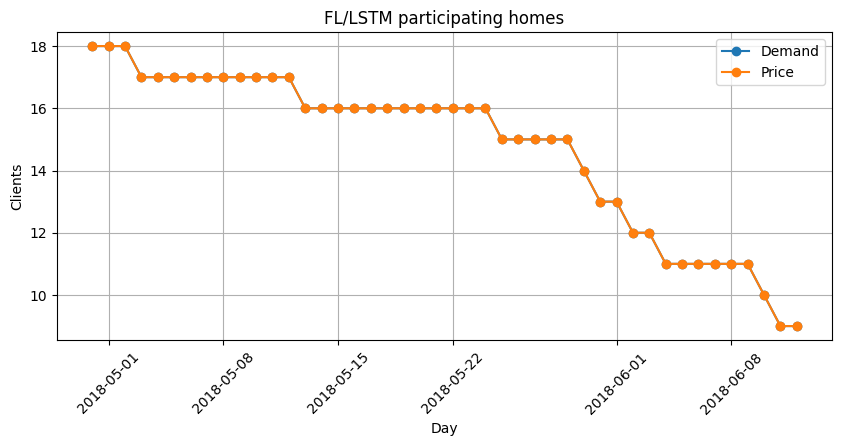

In [9]:
plt.figure(figsize=(10, 4))
if len(demand_fl_history) > 0:
    plt.plot(pd.to_datetime(demand_fl_history["day"]), demand_fl_history["num_clients"], marker="o", label="Demand")
if len(price_fl_history) > 0:
    plt.plot(pd.to_datetime(price_fl_history["day"]), price_fl_history["num_clients"], marker="o", label="Price")
plt.title("FL/LSTM participating homes")
plt.xlabel("Day")
plt.ylabel("Clients")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

## Stage 4 — Generate/load FL predictions

In [10]:
def add_fl_predictions_to_df(df, model, feature_cols, target_name, x_scaler, y_scaler, seq_len, horizon):
    df_out = df.copy().sort_values(["homeid", "timestamp"]).reset_index(drop=True)
    pred_cols = [f"{target_name}_fl_pred_t{i}" for i in range(1, horizon + 1)]

    for col in pred_cols:
        if col not in df_out.columns:
            df_out[col] = np.nan

    n_features = len(feature_cols)

    for homeid, group in df_out.groupby("homeid"):
        idx = group.index.to_numpy()
        X_vals = group[feature_cols].to_numpy(dtype=np.float32)

        if len(group) < seq_len:
            continue

        X_all = []
        row_indices = []

        for i in range(len(group) - seq_len + 1):
            X_all.append(X_vals[i:i + seq_len])
            row_indices.append(idx[i + seq_len - 1])

        X_all = np.asarray(X_all, dtype=np.float32)
        X_scaled = x_scaler.transform(X_all.reshape(-1, n_features)).reshape(X_all.shape)
        preds_scaled = model.predict(X_scaled, verbose=0)
        preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)

        for row_idx, pred_row in zip(row_indices, preds):
            for h in range(horizon):
                df_out.loc[row_idx, pred_cols[h]] = pred_row[h]

    return df_out


pred_path = os.path.join(RESULT_DIR, "df_with_fl_predictions.csv")

if cache_exists(pred_path) and not FORCE_REBUILD_PREDICTIONS:
    print("Loading cached prediction dataframe...")
    df_preds = pd.read_csv(pred_path)
    df_preds["timestamp"] = pd.to_datetime(df_preds["timestamp"], errors="coerce")
else:
    print("Generating FL prediction dataframe...")
    df_preds = add_fl_predictions_to_df(
        df=df_fed,
        model=demand_model,
        feature_cols=feature_cols,
        target_name="demand",
        x_scaler=x_scaler,
        y_scaler=demand_y_scaler,
        seq_len=SEQ_LEN,
        horizon=HORIZON,
    )

    df_preds = add_fl_predictions_to_df(
        df=df_preds,
        model=price_model,
        feature_cols=feature_cols,
        target_name="price",
        x_scaler=x_scaler,
        y_scaler=price_y_scaler,
        seq_len=SEQ_LEN,
        horizon=HORIZON,
    )

    df_preds.to_csv(pred_path, index=False)

print(df_preds.shape)
df_preds.head()

Generating FL prediction dataframe...
(33725, 26)


,timestamp,homeid,demand_kwh,solar_kwh,price_kwh,is_weekend,outdoor_temperature,price_kwh_original,hour_sin,hour_cos,...,demand_fl_pred_t3,demand_fl_pred_t4,demand_fl_pred_t5,demand_fl_pred_t6,price_fl_pred_t1,price_fl_pred_t2,price_fl_pred_t3,price_fl_pred_t4,price_fl_pred_t5,price_fl_pred_t6
0,2018-04-05 16:00:00,105,0.340619,5.308966e-02,0.047050,0,23.185000,0.022050,-0.866025,-5.000000e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-04-05 17:00:00,105,0.280234,3.972798e-02,0.049320,0,21.601667,0.024320,-0.965926,-2.588190e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-04-05 18:00:00,105,0.153885,1.866988e-17,0.051320,0,21.830000,0.026320,-1.000000,-1.836970e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-04-05 19:00:00,105,0.500623,0.000000e+00,0.053945,0,22.916667,0.028945,-0.965926,2.588190e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-04-05 20:00:00,105,0.468784,0.000000e+00,0.055840,0,23.818333,0.030840,-0.866025,5.000000e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def evaluate_prediction_mae(df_pred, actual_col, pred_base, horizon):
    rows = []
    df_eval = df_pred.sort_values(["homeid", "timestamp"]).copy()

    for h in range(1, horizon + 1):
        pred_col = f"{pred_base}_t{h}"
        future_col = f"{actual_col}_future_t{h}"
        df_eval[future_col] = df_eval.groupby("homeid")[actual_col].shift(-h)
        temp = df_eval[[pred_col, future_col]].dropna()

        rows.append({
            "horizon": h,
            "mae": mean_absolute_error(temp[future_col], temp[pred_col]),
            "rmse": np.sqrt(mean_squared_error(temp[future_col], temp[pred_col])),
        })

    return pd.DataFrame(rows)


demand_eval = evaluate_prediction_mae(df_preds, "demand_kwh", "demand_fl_pred", HORIZON)
price_eval = evaluate_prediction_mae(df_preds, "price_kwh", "price_fl_pred", HORIZON)

print("Demand forecast eval")
display(demand_eval)
print("Price forecast eval")
display(price_eval)

demand_eval.to_csv(os.path.join(RESULT_DIR, "demand_prediction_eval.csv"), index=False)
price_eval.to_csv(os.path.join(RESULT_DIR, "price_prediction_eval.csv"), index=False)

Demand forecast eval


,horizon,mae,rmse
0,1,0.235856,0.392749
1,2,0.243183,0.400359
2,3,0.234318,0.392688
3,4,0.228104,0.388624
4,5,0.268671,0.400891
5,6,0.247482,0.391640


Price forecast eval


,horizon,mae,rmse
0,1,0.004407,0.006322
1,2,0.004742,0.006554
2,3,0.004481,0.006354
3,4,0.005119,0.006852
4,5,0.004402,0.006436
5,6,0.004666,0.006460


## Core battery environment and baselines

In [12]:
@dataclass
class EnvConfig:
    obs_cols: list
    battery_capacity_kwh: float
    max_c_rate: float = MAX_C_RATE
    charge_efficiency: float = CHARGE_EFFICIENCY
    discharge_efficiency: float = DISCHARGE_EFFICIENCY
    initial_soc_frac: float = INITIAL_SOC_FRAC
    waste_penalty_per_kwh: float = WASTE_PENALTY_PER_KWH
    throughput_penalty_per_kwh: float = THROUGHPUT_PENALTY_PER_KWH
    allow_export: bool = False
    export_price_discount: float = 1.0


class BatteryControlEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, episodes: List[Dict[str, np.ndarray]], config: EnvConfig):
        super().__init__()
        if len(episodes) == 0:
            raise ValueError("No episodes supplied.")
        self.episodes = episodes
        self.cfg = config
        self.obs_cols = config.obs_cols
        obs_dim = len(self.obs_cols) + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.current_episode_idx = -1
        self.current_ep = None
        self.t = 0
        self.soc = 0.0

    def _max_power_kwh(self):
        return self.cfg.battery_capacity_kwh * self.cfg.max_c_rate

    def _get_obs(self):
        obs = self.current_ep["obs"][self.t]
        soc_frac = 0.0 if self.cfg.battery_capacity_kwh == 0 else self.soc / self.cfg.battery_capacity_kwh
        return np.concatenate([obs, np.array([soc_frac], dtype=np.float32)])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_episode_idx = (self.current_episode_idx + 1) % len(self.episodes)
        self.current_ep = self.episodes[self.current_episode_idx]
        self.t = 0
        self.soc = self.cfg.initial_soc_frac * self.cfg.battery_capacity_kwh
        return self._get_obs(), {}

    def step(self, action):
        demand = float(self.current_ep["demand"][self.t])
        solar = float(self.current_ep["solar"][self.t])
        price = float(self.current_ep["price"][self.t])
        timestamp = self.current_ep["timestamp"][self.t]

        net_load = demand - solar
        capacity = self.cfg.battery_capacity_kwh
        max_power = self._max_power_kwh()

        charge_in = 0.0
        discharge_out = 0.0

        if capacity > 0 and max_power > 0:
            if action == 0:
                max_input_allowed = max((capacity - self.soc) / self.cfg.charge_efficiency, 0.0)
                charge_in = min(max_power, max_input_allowed)
                self.soc += charge_in * self.cfg.charge_efficiency
            elif action == 2:
                available_output = min(max_power, self.soc * self.cfg.discharge_efficiency)
                discharge_out = min(available_output, max(net_load, 0.0)) if not self.cfg.allow_export else available_output
                self.soc -= discharge_out / self.cfg.discharge_efficiency
            self.soc = min(max(self.soc, 0.0), capacity)

        grid_after = net_load + charge_in - discharge_out
        grid_import = max(grid_after, 0.0)
        grid_export = max(-grid_after, 0.0)
        wasted = 0.0 if self.cfg.allow_export else grid_export
        export_revenue = grid_export * price * self.cfg.export_price_discount if self.cfg.allow_export else 0.0
        throughput = charge_in + discharge_out

        step_cost = (
            grid_import * price
            - export_revenue
            + self.cfg.waste_penalty_per_kwh * wasted
            + self.cfg.throughput_penalty_per_kwh * throughput
        )
        reward = -step_cost

        info = {
            "timestamp": timestamp,
            "homeid": self.current_ep["homeid"],
            "demand_kwh": demand,
            "solar_kwh": solar,
            "price_kwh": price,
            "net_load_kwh": net_load,
            "soc_kwh": self.soc,
            "grid_import_kwh": grid_import,
            "grid_export_kwh": grid_export,
            "wasted_kwh": wasted,
            "throughput_kwh": throughput,
            "step_cost": step_cost,
            "action": int(action),
        }

        self.t += 1
        terminated = self.t >= self.current_ep["length"]
        truncated = False
        next_obs = np.zeros(self.observation_space.shape, dtype=np.float32) if terminated else self._get_obs()
        return next_obs, float(reward), terminated, truncated, info

In [13]:
def make_episodes(df, obs_cols):
    episodes = []
    for homeid, group in df.groupby("homeid"):
        group = group.sort_values("timestamp").reset_index(drop=True)
        episodes.append({
            "homeid": homeid,
            "timestamp": group["timestamp"].to_numpy(),
            "obs": group[obs_cols].to_numpy(dtype=np.float32),
            "demand": group["demand_kwh"].to_numpy(dtype=np.float32),
            "solar": group["solar_kwh"].to_numpy(dtype=np.float32),
            "price": group["price_kwh"].to_numpy(dtype=np.float32),
            "length": len(group),
        })
    return episodes


def validate_episodes(episodes):
    for i, ep in enumerate(episodes):
        for key in ["obs", "demand", "solar", "price"]:
            arr = ep[key]
            if np.isnan(arr).any():
                raise ValueError(f"NaN found in episode {i}, key={key}")
            if np.isinf(arr).any():
                raise ValueError(f"Inf found in episode {i}, key={key}")
    print("Episodes OK")


def evaluate_agent(model, env):
    all_infos = []
    rewards = []
    obs, _ = env.reset()
    total_reward = 0

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        all_infos.append(info)

        if terminated or truncated:
            rewards.append(total_reward)
            if env.unwrapped.current_episode_idx == len(env.unwrapped.episodes) - 1:
                break
            obs, _ = env.reset()
            total_reward = 0

    return pd.DataFrame(all_infos), rewards


def evaluate_no_battery(df):
    net_load = df["demand_kwh"] - df["solar_kwh"]
    grid_import = np.maximum(net_load, 0)
    wasted = np.maximum(-net_load, 0)
    cost = grid_import * df["price_kwh"]
    return {
        "total_cost": float(cost.sum()),
        "grid_import_kwh": float(grid_import.sum()),
        "wasted_kwh": float(wasted.sum()),
    }

## Stage 5 — Prepare/load RL data

In [14]:
fl_pred_cols = (
    [f"demand_fl_pred_t{i}" for i in range(1, HORIZON + 1)] +
    [f"price_fl_pred_t{i}" for i in range(1, HORIZON + 1)]
)

fed_rl_obs_cols = [
    "demand_kwh",
    "solar_kwh",
    "price_kwh",
    "outdoor_temperature",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
] + fl_pred_cols

stage_rl_path = os.path.join(CACHE_DIR, "stage_rl_data.pkl")

if cache_exists(stage_rl_path) and not FORCE_REBUILD_DATA:
    df_rl, train_df_rl, test_df_rl, fed_rl_obs_cols = load_pickle(stage_rl_path)
    stage_message("stage_rl_data", loaded=True)
else:
    df_rl = df_preds.dropna(subset=fed_rl_obs_cols).copy()
    rl_clean_cols = list(dict.fromkeys(fed_rl_obs_cols + ["demand_kwh", "solar_kwh", "price_kwh"]))
    df_rl[rl_clean_cols] = df_rl[rl_clean_cols].replace([np.inf, -np.inf], np.nan)
    df_rl[rl_clean_cols] = df_rl.groupby("homeid")[rl_clean_cols].transform(lambda x: x.ffill().bfill())
    df_rl[rl_clean_cols] = df_rl[rl_clean_cols].fillna(0)
    train_df_rl, test_df_rl = split_df_per_home(df_rl, test_size=TEST_SIZE)
    save_pickle((df_rl, train_df_rl, test_df_rl, fed_rl_obs_cols), stage_rl_path)
    stage_message("stage_rl_data", loaded=False)

fed_rl_config = EnvConfig(
    obs_cols=fed_rl_obs_cols,
    battery_capacity_kwh=BATTERY_CAPACITY_KWH,
    max_c_rate=MAX_C_RATE,
    charge_efficiency=CHARGE_EFFICIENCY,
    discharge_efficiency=DISCHARGE_EFFICIENCY,
    initial_soc_frac=INITIAL_SOC_FRAC,
    waste_penalty_per_kwh=WASTE_PENALTY_PER_KWH,
    throughput_penalty_per_kwh=THROUGHPUT_PENALTY_PER_KWH,
    allow_export=False,
)

print("RL train rows:", len(train_df_rl))
print("RL test rows:", len(test_df_rl))
print("RL obs cols:", len(fed_rl_obs_cols))

Built stage: stage_rl_data
RL train rows: 25836
RL test rows: 6469
RL obs cols: 23


## Stage 6 — Train/load federated PPO

In [15]:
def average_ppo_policy_parameters(local_models, weights=None):
    if weights is None:
        weights = np.ones(len(local_models), dtype=np.float32)
    else:
        weights = np.asarray(weights, dtype=np.float32)
    weights = weights / weights.sum()

    params = [m.get_parameters() for m in local_models]
    avg_params = copy.deepcopy(params[0])

    for key in avg_params["policy"]:
        avg_params["policy"][key] = sum(
            weights[i] * params[i]["policy"][key]
            for i in range(len(params))
        )

    return {"policy": avg_params["policy"]}


def train_federated_ppo(train_df, obs_cols, config, n_rounds=4, homes_per_round=8, local_timesteps=500, seed=42):
    rng = np.random.default_rng(seed)
    home_ids = train_df["homeid"].drop_duplicates().to_numpy()

    dummy_home = home_ids[0]
    dummy_df = train_df[train_df["homeid"] == dummy_home].copy()
    dummy_env = Monitor(BatteryControlEnv(make_episodes(dummy_df, obs_cols), config))

    global_model = PPO(
        "MlpPolicy",
        dummy_env,
        learning_rate=3e-4,
        n_steps=256,
        batch_size=64,
        n_epochs=3,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=0,
        device="cpu",
    )

    logs = []

    for r in range(n_rounds):
        selected_homes = rng.choice(home_ids, size=min(homes_per_round, len(home_ids)), replace=False)
        local_models = []
        sample_weights = []

        print(f"Fed PPO round {r + 1}/{n_rounds} | selected homes={len(selected_homes)}")

        for homeid in selected_homes:
            home_df = train_df[train_df["homeid"] == homeid].copy()
            if len(home_df) < 24:
                continue

            env = Monitor(BatteryControlEnv(make_episodes(home_df, obs_cols), config))
            local_model = PPO(
                "MlpPolicy",
                env,
                learning_rate=3e-4,
                n_steps=256,
                batch_size=64,
                n_epochs=3,
                gamma=0.99,
                gae_lambda=0.95,
                clip_range=0.2,
                ent_coef=0.01,
                verbose=0,
                device="cpu",
            )

            local_model.set_parameters(global_model.get_parameters(), exact_match=True)
            local_model.learn(total_timesteps=local_timesteps, reset_num_timesteps=False)
            local_models.append(local_model)
            sample_weights.append(len(home_df))

        if len(local_models) > 0:
            avg_params = average_ppo_policy_parameters(local_models, weights=sample_weights)
            global_model.set_parameters(avg_params, exact_match=False)
            logs.append({
                "round": r + 1,
                "num_clients": len(local_models),
                "total_samples": int(np.sum(sample_weights)),
            })

        del local_models
        gc.collect()

    return global_model, pd.DataFrame(logs)

In [16]:
ppo_model_path = os.path.join(MODEL_DIR, "fl_ppo_battery_control.zip")
ppo_history_path = os.path.join(RESULT_DIR, "fed_ppo_history.csv")

if cache_exists(ppo_model_path) and not FORCE_RETRAIN_PPO:
    print("Loading cached FL/PPO model...")
    fed_ppo_model = PPO.load(ppo_model_path)
    fed_ppo_history = pd.read_csv(ppo_history_path) if cache_exists(ppo_history_path) else pd.DataFrame()
else:
    print("Training FL/PPO model...")
    fed_ppo_model, fed_ppo_history = train_federated_ppo(
        train_df=train_df_rl,
        obs_cols=fed_rl_obs_cols,
        config=fed_rl_config,
        n_rounds=PPO_ROUNDS,
        homes_per_round=PPO_HOMES_PER_ROUND,
        local_timesteps=PPO_LOCAL_TIMESTEPS,
        seed=RANDOM_STATE,
    )
    fed_ppo_model.save(os.path.join(MODEL_DIR, "fl_ppo_battery_control"))
    fed_ppo_history.to_csv(ppo_history_path, index=False)

fed_ppo_history

Training FL/PPO model...
Fed PPO round 1/4 | selected homes=8
Fed PPO round 2/4 | selected homes=8
Fed PPO round 3/4 | selected homes=8
Fed PPO round 4/4 | selected homes=8


,round,num_clients,total_samples
0,1,8,10824
1,2,8,9260
2,3,8,10421
3,4,8,10062


## Stage 7 — Evaluate/load FL/PPO results and baselines

In [17]:
def evaluate_oracle_greedy_baseline(df, config, horizon=6):
    """A lightweight oracle baseline using actual future prices over the next H hours.
    This is not a mathematical optimum, but is a strong perfect-foresight heuristic baseline.
    """
    rows = []

    for homeid, group in df.groupby("homeid"):
        group = group.sort_values("timestamp").reset_index(drop=True)
        soc = config.initial_soc_frac * config.battery_capacity_kwh
        capacity = config.battery_capacity_kwh
        max_power = capacity * config.max_c_rate

        for t in range(len(group)):
            demand = float(group.loc[t, "demand_kwh"])
            solar = float(group.loc[t, "solar_kwh"])
            price = float(group.loc[t, "price_kwh"])
            net_load = demand - solar

            future_prices = group.loc[t:min(t + horizon, len(group)-1), "price_kwh"].to_numpy()
            if len(future_prices) == 0:
                future_prices = np.array([price])

            low = np.percentile(future_prices, 30)
            high = np.percentile(future_prices, 70)

            if price <= low and soc < capacity * 0.95:
                action = 0
            elif price >= high and soc > capacity * 0.05:
                action = 2
            else:
                action = 1

            charge_in = 0.0
            discharge_out = 0.0

            if action == 0:
                max_input_allowed = max((capacity - soc) / config.charge_efficiency, 0.0)
                charge_in = min(max_power, max_input_allowed)
                soc += charge_in * config.charge_efficiency
            elif action == 2:
                available_output = min(max_power, soc * config.discharge_efficiency)
                discharge_out = min(available_output, max(net_load, 0.0))
                soc -= discharge_out / config.discharge_efficiency

            soc = min(max(soc, 0.0), capacity)

            grid_after = net_load + charge_in - discharge_out
            grid_import = max(grid_after, 0.0)
            wasted = max(-grid_after, 0.0)
            cost = grid_import * price + config.throughput_penalty_per_kwh * (charge_in + discharge_out)

            rows.append({
                "timestamp": group.loc[t, "timestamp"],
                "homeid": homeid,
                "action": action,
                "soc_kwh": soc,
                "grid_import_kwh": grid_import,
                "wasted_kwh": wasted,
                "step_cost": cost,
            })

    return pd.DataFrame(rows)

In [18]:
results_path = os.path.join(RESULT_DIR, "fl_ppo_results.csv")
oracle_path = os.path.join(RESULT_DIR, "oracle_results.csv")
comparison_path = os.path.join(RESULT_DIR, "final_comparison.csv")

if cache_exists(results_path) and cache_exists(oracle_path) and cache_exists(comparison_path) and not FORCE_REEVALUATE:
    print("Loading cached evaluation results...")
    fed_ppo_results = pd.read_csv(results_path)
    oracle_results = pd.read_csv(oracle_path)
    comparison = pd.read_csv(comparison_path)
else:
    print("Evaluating FL/PPO and baselines...")
    test_episodes_rl = make_episodes(test_df_rl, fed_rl_obs_cols)
    validate_episodes(test_episodes_rl)

    fed_ppo_test_env = Monitor(BatteryControlEnv(test_episodes_rl, fed_rl_config))
    fed_ppo_results, fed_ppo_rewards = evaluate_agent(fed_ppo_model, fed_ppo_test_env)

    no_battery = evaluate_no_battery(test_df_rl)
    oracle_results = evaluate_oracle_greedy_baseline(test_df_rl, fed_rl_config, horizon=HORIZON)

    comparison = pd.DataFrame([
        {
            "method": "No battery",
            "total_cost": no_battery["total_cost"],
            "grid_import_kwh": no_battery["grid_import_kwh"],
            "wasted_kwh": no_battery["wasted_kwh"],
        },
        {
            "method": "Oracle greedy baseline",
            "total_cost": oracle_results["step_cost"].sum(),
            "grid_import_kwh": oracle_results["grid_import_kwh"].sum(),
            "wasted_kwh": oracle_results["wasted_kwh"].sum(),
        },
        {
            "method": "FL/LSTM + FL/PPO",
            "total_cost": fed_ppo_results["step_cost"].sum(),
            "grid_import_kwh": fed_ppo_results["grid_import_kwh"].sum(),
            "wasted_kwh": fed_ppo_results["wasted_kwh"].sum(),
        },
    ])

    no_battery_cost = comparison.loc[comparison["method"] == "No battery", "total_cost"].iloc[0]
    oracle_cost = comparison.loc[comparison["method"] == "Oracle greedy baseline", "total_cost"].iloc[0]

    comparison["saving_vs_no_battery_%"] = ((no_battery_cost - comparison["total_cost"]) / no_battery_cost) * 100
    comparison["cost_gap_vs_oracle_%"] = ((comparison["total_cost"] - oracle_cost) / oracle_cost) * 100

    fed_ppo_results.to_csv(results_path, index=False)
    oracle_results.to_csv(oracle_path, index=False)
    comparison.to_csv(comparison_path, index=False)

comparison

Evaluating FL/PPO and baselines...
Episodes OK


,method,total_cost,grid_import_kwh,wasted_kwh,saving_vs_no_battery_%,cost_gap_vs_oracle_%
0,No battery,94.632182,1827.407857,357.126166,0.000000,1.418666
1,Oracle greedy baseline,93.308446,1899.249706,330.915197,1.398822,0.000000
2,FL/LSTM + FL/PPO,88.568837,1702.978181,239.605295,6.407276,-5.079508


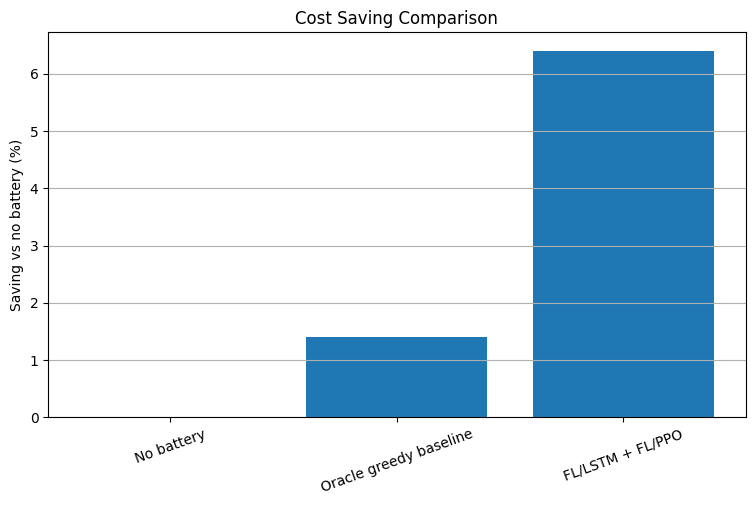

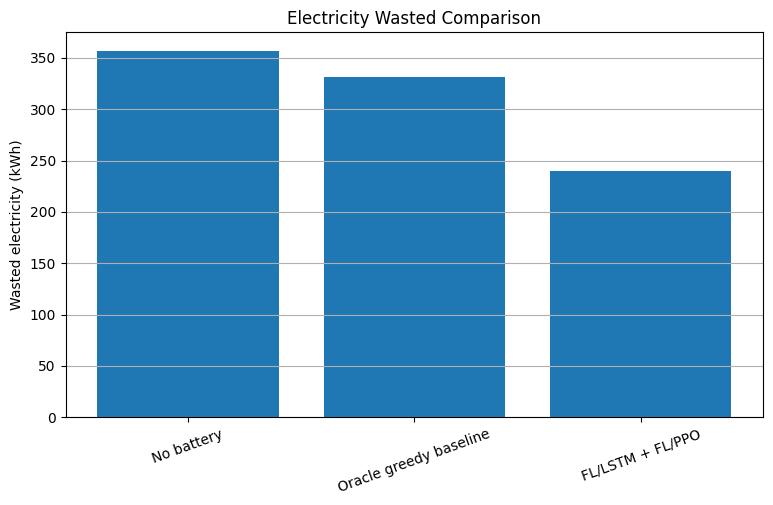

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["method"], comparison["saving_vs_no_battery_%"])
plt.ylabel("Saving vs no battery (%)")
plt.title("Cost Saving Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(comparison["method"], comparison["wasted_kwh"])
plt.ylabel("Wasted electricity (kWh)")
plt.title("Electricity Wasted Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

## Save final metadata

This cell stores the exact settings and feature columns needed to reproduce or reload the run.

In [20]:
metadata = {
    "data_path": DATA_PATH,
    "cache_dir": CACHE_DIR,
    "random_state": RANDOM_STATE,
    "n_fed_homes": N_FED_HOMES,
    "seq_len": SEQ_LEN,
    "horizon": HORIZON,
    "test_size": TEST_SIZE,
    "feature_cols": feature_cols,
    "fed_rl_obs_cols": fed_rl_obs_cols,
    "battery_capacity_kwh": BATTERY_CAPACITY_KWH,
    "max_c_rate": MAX_C_RATE,
    "charge_efficiency": CHARGE_EFFICIENCY,
    "discharge_efficiency": DISCHARGE_EFFICIENCY,
    "initial_soc_frac": INITIAL_SOC_FRAC,
    "waste_penalty_per_kwh": WASTE_PENALTY_PER_KWH,
    "throughput_penalty_per_kwh": THROUGHPUT_PENALTY_PER_KWH,
}

save_json(metadata, os.path.join(CACHE_DIR, "run_metadata.json"))
print("Saved run metadata to", os.path.join(CACHE_DIR, "run_metadata.json"))
print("Final comparison saved to", comparison_path)

Saved run metadata to cache_fast_fl_pipeline\run_metadata.json
Final comparison saved to cache_fast_fl_pipeline\results\final_comparison.csv
